In [5]:
from graphviz import Digraph

def create_panopticon_arch():
    dot = Digraph('MultiSensor_Panopticon', format='png')
    dot.attr(dpi='300', rankdir='TB', compound='true')
    dot.attr('node', fontname='Arial', shape='box', style='filled,rounded', fontsize='12')

    # --- 1. Multi-Sensor Input Stage (PE) ---
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='I. Sensor-Specific Patch Embedding', style='dashed', fontcolor='blue')
        sensors = [
            ('s2', 'Sentinel-2', '#CCEBC5'),
            ('l89', 'Landsat 8/9', '#B3CDE3'),
            ('s5p', 'TROPOMI (S5P)', '#DECBE4')
        ]
        for key, name, color in sensors:
            # 简化代码中的 Conv3d + ChnAttn + Proj
            c.node(f'PE_{key}', f'{name} PE\n(Conv3D + ChnAttn)', fillcolor=color)

    # --- 2. Shared Backbone (ViT Blocks) ---
    with dot.subgraph(name='cluster_backbone') as c:
        c.attr(label='II. Universal Backbone (DinoV2 Based)', style='filled', fillcolor='#F9F9F9')
        
        # 内部展示一个典型的 Block 结构，体现 DS-LN
        c.node('LN1', 'Domain-Specific LN 1\n(Selects s2/l89/s5p parameters)', fillcolor='#FFD1D1', color='red', penwidth='2')
        c.node('Attn', 'Shared Attention\n(Global Context)', fillcolor='#FFF2CC')
        c.node('LN2', 'Domain-Specific LN 2', fillcolor='#FFD1D1', color='red', penwidth='2')
        c.node('FFN_1', 'Domain-Specific SwiGLU FFN 1', fillcolor='#FFD1D1', color='red', penwidth='2')
        c.node('FFN_2', 'Shared SwiGLU FFN 2\n(Knowledge Base)', fillcolor='#FFF2CC')
        
        c.edge('LN1', 'Attn')
        c.edge('Attn', 'LN2')
        c.edge('LN2', 'FFN_1')
        c.edge('FFN_1', 'FFN_2')
        
        # 标注 12层 堆叠
        c.node('Stack', '... Repeat x12 Blocks ...', shape='none', style='')
        c.edge('FFN_2', 'Stack')

    # --- 3. Output Heads ---
    with dot.subgraph(name='cluster_heads') as c:
        c.attr(label='III. Task-Specific Heads', style='dashed', fontcolor='green')
        for key, name, color in sensors:
            c.node(f'Head_{key}', f'CLS Head ({name})\nMethane Yes/No', fillcolor=color)

    # --- 连接全局 ---
    for key, _, _ in sensors:
        dot.edge(f'PE_{key}', 'LN1', lhead='cluster_backbone')
        dot.edge('Stack', f'Head_{key}', ltail='cluster_backbone')

    dot.render('panopticon_final_arch', cleanup=True)
    print("架构图已生成：panopticon_final_arch.png")

if __name__ == "__main__":
    create_panopticon_arch()

架构图已生成：panopticon_final_arch.png


In [ ]:
from graphviz import Digraph

def create_no_container_arch():
    # compound=true 仍然保留，以确保整体布局严谨
    dot = Digraph('Panopticon_No_Container', format='png')
    dot.attr(dpi='300', rankdir='TB', compound='true')
    dot.attr('node', fontname='Arial', shape='box', style='filled,rounded', fontsize='12')

    # --- 1. Sensor-Specific Input (PE) ---
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='I. Sensor-Specific Patch Embedding', style='dashed', fontcolor='#444444')
        sensors = [('s2', 'Sentinel-2', '#CCEBC5'), ('l89', 'Landsat 8/9', '#B3CDE3'), ('s5p', 'S5P (TROPOMI)', '#DECBE4')]
        for key, name, color in sensors:
            c.node(f'PE_{key}', f'{name} PE\n(3D Conv + ChnAttn)', fillcolor=color)

    # --- 2. Backbone (已经去掉了内部的 5x Adapter 容器) ---
    with dot.subgraph(name='cluster_backbone') as c:
        c.attr(label='II. Hybrid ViT Backbone', style='filled', fillcolor='#F9F9F9')
        
        c.node('Blocks_Shared', '7 x Shared Transformer Blocks\n(Universal Features)', fillcolor='#FFF2CC', width='4')
        
        # 直接定义原本在容器内的节点
        # 核心分叉点 (Input X)
        dot.node('Split', '', shape='point', width='0.1')
        
        # 中心主干道
        dot.node('Shared_Core', '5 x Shared NestedTensorBlock\n(Attn + MLP)', fillcolor='#FFF2CC', penwidth='2', width='3')
        
        # 侧边旁路适配器
        dot.node('Ad_S2', 'Tiny Adapter\n(Sentinel-2)', fillcolor='#CCEBC5', style='filled,dashed')
        dot.node('Ad_L89', 'Tiny Adapters\n(Landsat-8/9)', fillcolor='#B3CDE3', style='filled,dashed')
        dot.node('Ad_S5p', 'Tiny Adapters\n(Sentinel-5p)', fillcolor='#FFD1D1', style='filled,dashed')
        
        # 核心汇合点
        dot.node('Sum', 'Sum (+)', shape='circle', fillcolor='#D1FFD1')

        # 保持横向对齐逻辑
        with dot.subgraph() as s:
            s.attr(rank='same')
            dot.node('Ad_S2')
            dot.node('Shared_Core')
            dot.node('Ad_L89')
            dot.node('Ad_S5p')

        # --- 内部连线逻辑 ---
        # 增加从 Blocks_Shared 到 Split 的权重和距离
        dot.edge('Blocks_Shared', 'Split', minlen='1.2')
        
        # 主干直线
        dot.edge('Split', 'Shared_Core', weight='10')
        dot.edge('Shared_Core', 'Sum', weight='10')
        
        # 并行分叉
        dot.edge('Split', 'Ad_S2', style='dashed')
        dot.edge('Split', 'Ad_L89', style='dashed')
        dot.edge('Split', 'Ad_S5p', style='dashed')
        
        # 汇合
        dot.edge('Ad_S2', 'Sum', style='dashed')
        dot.edge('Ad_L89', 'Sum', style='dashed')
        dot.edge('Ad_S5p', 'Sum', style='dashed')

    # --- 3. Classifier Heads ---
    with dot.subgraph(name='cluster_heads') as c:
        c.attr(label='III. Specialized CLS Heads', style='dashed')
        c.node('H_S2', 'Head (Sentinel-2)', fillcolor='#CCEBC5')
        c.node('H_L89', 'Head (Landsat 8/9)', fillcolor='#B3CDE3')
        c.node('H_S5p', 'Head (Sentinel-5p)', fillcolor='#FFD1D1')

    # --- 全局连线 ---
    for key, _, _ in sensors:
        dot.edge(f'PE_{key}', 'Blocks_Shared')
    
    # 直接连向 Head
    dot.edge('Sum', 'H_S2')
    dot.edge('Sum', 'H_L89')
    dot.edge('Sum', 'H_S5p')

    dot.render('panopticon_no_container', cleanup=True)
    print("架构图已生成：panopticon_residual_adapter.png")

if __name__ == "__main__":
    create_no_container_arch()

架构图已生成（去掉了 Adapter 容器）：panopticon_residual_adapter.png


In [ ]:
from graphviz import Digraph

def create_modified_arch():
    dot = Digraph('Panopticon_Modified', format='png')
    dot.attr(dpi='300', rankdir='TB', compound='true')
    dot.attr('node', fontname='Arial', shape='box', style='filled,rounded', fontsize='12')

    # --- 1. Sensor-Specific Input (PE) ---
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='I. Sensor-Specific Patch Embedding', style='dashed', fontcolor='#444444')
        sensors = [('s2', 'Sentinel-2', '#CCEBC5'), ('l89', 'Landsat 8/9', '#B3CDE3'), ('s5p', 'S5P (TROPOMI)', '#DECBE4')]
        for key, name, color in sensors:
            c.node(f'PE_{key}', f'{name} PE\n(3D Conv + ChnAttn)', fillcolor=color)

    # --- 2. Adapter Stage (First 5 Layers - Frozen Backbone) ---
    with dot.subgraph(name='cluster_adapters') as c:
        c.attr(label='II. Adapter Stage (First 5 Layers)\n[Backbone Frozen]', style='filled', fillcolor='#F0F0F0')
        
        # Logic nodes
        c.node('Split', 'Input Split', shape='point', width='0.1')
        c.node('Sum', 'Sum (+)', shape='circle', fillcolor='#D1FFD1')
        
        # The Frozen Backbone part
        c.node('Shared_Core', '5 x Shared NestedTensorBlock\n(FROZEN)', fillcolor='#E0E0E0', fontcolor='#777777', penwidth='2')
        
        # The Active Adapters
        c.node('Ad_S2', 'Tiny Adapter\n(Sentinel-2)', fillcolor='#CCEBC5', style='filled,dashed')
        c.node('Ad_L89', 'Tiny Adapters\n(Landsat-8/9)', fillcolor='#B3CDE3', style='filled,dashed')
        c.node('Ad_S5p', 'Tiny Adapters\n(S5P)', fillcolor='#FFD1D1', style='filled,dashed')

        # Alignment
        with c.subgraph() as s:
            s.attr(rank='same')
            s.node('Ad_S2')
            s.node('Shared_Core')
            s.node('Ad_L89')
            s.node('Ad_S5p')

        # Internal Connections
        c.edge('Split', 'Shared_Core', weight='10')
        c.edge('Shared_Core', 'Sum', weight='10')
        c.edge('Split', 'Ad_S2', style='dashed')
        c.edge('Split', 'Ad_L89', style='dashed')
        c.edge('Split', 'Ad_S5p', style='dashed')
        c.edge('Ad_S2', 'Sum', style='dashed')
        c.edge('Ad_L89', 'Sum', style='dashed')
        c.edge('Ad_S5p', 'Sum', style='dashed')

    # --- 3. Shared Backbone (Last 7 Layers) ---
    with dot.subgraph(name='cluster_shared') as c:
        c.attr(label='III. Global Feature Extraction (Last 7 Layers)', style='filled', fillcolor='#F9F9F9')
        c.node('Blocks_Shared', '7 x Shared Transformer Blocks\n(Universal Features)', fillcolor='#FFF2CC', width='4')

    # --- 4. Classifier Heads ---
    with dot.subgraph(name='cluster_heads') as c:
        c.attr(label='IV. Specialized CLS Heads', style='dashed')
        c.node('H_S2', 'Head (Sentinel-2)', fillcolor='#CCEBC5')
        c.node('H_L89', 'Head (Landsat 8/9)', fillcolor='#B3CDE3')
        c.node('H_S5p', 'Head (S5P)', fillcolor='#FFD1D1')

    # --- Global Flow ---
    for key, _, _ in sensors:
        dot.edge(f'PE_{key}', 'Split')
    
    dot.edge('Sum', 'Blocks_Shared')
    
    dot.edge('Blocks_Shared', 'H_S2')
    dot.edge('Blocks_Shared', 'H_L89')
    dot.edge('Blocks_Shared', 'H_S5p')

    dot.render('panopticon_updated_arch', cleanup=True, view=False)
    print("Graph generated: panopticon_updated_arch.png")

if __name__ == "__main__":
    create_modified_arch()

In [ ]:
from graphviz import Digraph

def create_panopticon_emit_arch():
    dot = Digraph('Panopticon_EMIT', format='png')
    dot.attr(dpi='300', rankdir='TB', compound='true')
    dot.attr('node', fontname='Arial', shape='box', style='filled,rounded', fontsize='12')

    # Color Palette
    c_s2 = '#CCEBC5'   # Green
    c_l89 = '#B3CDE3'  # Blue
    c_s5p = '#DECBE4'  # Purple
    c_emit = '#FFF9C4' # Yellow (EMIT/WV3)

    # --- 1. Sensor-Specific Input (PE) ---
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='I. Sensor-Specific Patch Embedding', style='dashed', fontcolor='#444444')
        sensors = [
            ('s2', 'Sentinel-2', c_s2), 
            ('l89', 'Landsat 8/9', c_l89), 
            ('s5p', 'S5P (TROPOMI)', c_s5p),
            ('emit', 'EMIT (Sim. WV-3)', c_emit) # New Sensor
        ]
        for key, name, color in sensors:
            c.node(f'PE_{key}', f'{name} PE\n(3D Conv + ChnAttn)', fillcolor=color)

    # --- 2. Adapter Stage (First 5 Layers) ---
    with dot.subgraph(name='cluster_adapters') as c:
        c.attr(label='II. Adapter Stage (First 5 Layers)\n[Backbone Frozen]', style='filled', fillcolor='#F0F0F0')
        
        dot.node('Split', 'Input Split', shape='point', width='0.1')
        dot.node('Sum', 'Sum (+)', shape='circle', fillcolor='#D1FFD1')
        
        # Frozen Backbone Core
        dot.node('Shared_Core', '5 x Shared NestedTensorBlock\n(FROZEN)', fillcolor='#E0E0E0', fontcolor='#777777', penwidth='2')
        
        # Adapters (Include new EMIT adapter)
        dot.node('Ad_S2', 'Tiny Adapter\n(Sentinel-2)', fillcolor=c_s2, style='filled,dashed')
        dot.node('Ad_L89', 'Tiny Adapter\n(Landsat-8/9)', fillcolor=c_l89, style='filled,dashed')
        dot.node('Ad_S5p', 'Tiny Adapter\n(S5P)', fillcolor=c_s5p, style='filled,dashed')
        dot.node('Ad_EMIT', 'Tiny Adapter\n(EMIT/WV-3)', fillcolor=c_emit, style='filled,dashed') # New Adapter

        # Horizontal Alignment
        with dot.subgraph() as s:
            s.attr(rank='same')
            dot.node('Ad_S2')
            dot.node('Ad_L89')
            dot.node('Shared_Core')
            dot.node('Ad_S5p')
            dot.node('Ad_EMIT')

        # Logic Flow
        dot.edge('Split', 'Shared_Core', weight='10')
        dot.edge('Shared_Core', 'Sum', weight='10')
        
        for key in ['S2', 'L89', 'S5p', 'EMIT']:
            dot.edge('Split', f'Ad_{key}', style='dashed')
            dot.edge(f'Ad_{key}', 'Sum', style='dashed')

    # --- 3. Shared Backbone (Last 7 Layers) ---
    with dot.subgraph(name='cluster_shared') as c:
        c.attr(label='III. Global Feature Extraction (Last 7 Layers)', style='filled', fillcolor='#F9F9F9')
        dot.node('Blocks_Shared', '7 x Shared Transformer Blocks\n(Universal Features)', fillcolor='#FFF2CC', width='5')

    # --- 4. Specialized Heads ---
    with dot.subgraph(name='cluster_heads') as c:
        c.attr(label='IV. Specialized CLS Heads', style='dashed')
        dot.node('H_S2', 'Head (Sentinel-2)', fillcolor=c_s2)
        dot.node('H_L89', 'Head (Landsat 8/9)', fillcolor=c_l89)
        dot.node('H_S5p', 'Head (S5P)', fillcolor=c_s5p)
        dot.node('H_EMIT', 'Head (EMIT/WV-3)', fillcolor=c_emit) # New Head

    # --- Global Connections ---
    for key, _, _ in sensors:
        dot.edge(f'PE_{key}', 'Split')
    
    dot.edge('Sum', 'Blocks_Shared')
    
    for key in ['S2', 'L89', 'S5p', 'EMIT']:
        dot.edge('Blocks_Shared', f'H_{key}')

    dot.render('panopticon_emit_wv3', cleanup=True)
    print("Graph updated with EMIT/WV-3 nodes.")

if __name__ == "__main__":
    create_panopticon_emit_arch()

Graph updated with EMIT/WV-3 nodes.


In [ ]:
from graphviz import Digraph

def create_panopticon_emit_arch():
    dot = Digraph('Panopticon_EMIT_Visual', format='png')
    dot.attr(dpi='300', rankdir='TB', compound='true', nodesep='0.4', ranksep='0.6')
    
    # 默认节点样式：强调简洁
    dot.attr('node', fontname='Arial', shape='box', style='filled,rounded', fontsize='11')
    dot.attr('edge', fontname='Arial', fontsize='9', color='#666666')

    # 颜色与状态定义
    c_s2, c_l89, c_s5p, c_emit = '#CCEBC5', '#B3CDE3', '#DECBE4', '#FFF9C4'
    c_train = "#00FF00" # 训练中标记色
    c_freeze = "#FF0000" # 冻结标记色 (用于Legend说明)

    # =========================================================================
    # 核心改进：增加一个横向的“训练阶段控制轴” (Stage Control)
    # =========================================================================
    with dot.subgraph(name='cluster_strategy') as s:
        s.attr(label='IV. Dynamic Training Strategy', style='rounded,filled', fillcolor='#FDF5E6', color='#E67E22')
        s.node('S1', 'Phase 1: Warm-up\n(Epoch 1-4)\n[All Active]', fillcolor='#D5F5E3')
        s.node('S2', 'Phase 2: Adaptation\n(Epoch 5+)\n[Backbone Frozen]', fillcolor='#FADBD8')
        s.node('S3', 'Individual Branch Control\n[Overfit -> Rollback & Freeze]', fillcolor='#EBEDEF', shape='diamond')
        s.edge('S1', 'S2', label='Transition')
        s.edge('S2', 'S3', style='dashed')

    # =========================
    # I. Sensor Inputs (标注：Always Trainable)
    # =========================
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='I. Input Stems (Trainable)', style='dashed')
        sensors = [('S2', c_s2), ('L89', c_l89), ('S5P', c_s5p), ('EMIT', c_emit)]
        for name, color in sensors:
            c.node(f'PE_{name}', f'{name} Stem\n(3D Conv + ChnAttn)', fillcolor=color)

    # =========================
    # II. Backbone (标注状态切换)
    # =========================
    with dot.subgraph(name='cluster_backbone') as c:
        c.attr(label='II. Hybrid Backbone', style='filled', fillcolor='#F7F7F7')
        
        c.node('Backbone12', 'Shared ViT Backbone\n(Frozen in Phase 2)', fillcolor='#E6E6E6', style='filled,bold')
        
        # 适配器标注为 Phase 2 的重点
        for name, color in sensors:
            c.node(f'Ad_{name}', f'Adapter\n({name})', fillcolor=color, style='filled,dashed')
        
        c.node('Sum', 'Fusion', shape='circle', width='0.5')

    # =========================
    # III. Heads (标注：Final Aggregator)
    # =========================
    with dot.subgraph(name='cluster_heads') as c:
        c.attr(label='III. Task Heads', style='dashed')
        for name, color in sensors:
            c.node(f'H_{name}', f'{name} Head', fillcolor=color)
        c.node('H_OVERALL', 'Overall Head\n(Always Trainable)', fillcolor='#FFD9B3', style='filled,bold', penwidth='2')

    # =========================
    # 建立连接与流程逻辑
    # =========================
    # 数据流
    for name, _ in sensors:
        dot.edge(f'PE_{name}', 'Backbone12')
        dot.edge(f'PE_{name}', f'Ad_{name}', style='dotted', label='trainable')
        dot.edge(f'Ad_{name}', 'Sum')
        dot.edge('Sum', f'H_{name}')
        dot.edge(f'H_{name}', 'H_OVERALL')
    dot.edge('Backbone12', 'Sum')

    # 策略关联：将策略节点指向它们控制的对象（逻辑示意）
    dot.edge('S1', 'Backbone12', color='#2ECC71', constraint='false', style='bold')
    dot.edge('S2', 'Backbone12', label='Freeze', color='#E74C3C', constraint='false', style='bold')
    dot.edge('S3', 'H_S2', label='Check Validation Loss', style='dashed', constraint='false')

    dot.render('panopticon_visual_logic', cleanup=True)

if __name__ == "__main__":
    create_panopticon_emit_arch()

In [23]:
from graphviz import Digraph

def draw_balanced_adapter_block():
    dot = Digraph('SensorAdapterBlock_Balanced', format='png')
    dot.attr(dpi='300', rankdir='LR', compound='true')
    dot.attr('node', fontname='Arial', shape='box', style='filled,rounded', fontsize='12')

    # --- 输入节点：保持精简尺寸 ---
    dot.node('input', 'Input Feature\n(768-dim)', shape='circle', 
             fillcolor='#E1E1E1', width='0.8', height='0.8', fixedsize='true', fontsize='10')

    # --- 1. 主路径 (Shared Block) ---
    with dot.subgraph(name='cluster_main') as c:
        c.attr(label='Shared Block', style='filled', fillcolor='#F0F0F0')
        # block_core 现在会被 minlen 推向右侧
        c.node('block_core', 'Standard NestedTensorBlock\n(Attn + MLP + Internal Residuals)', fillcolor='#FFF2CC')

    # --- 2. 适配器路径 (Parallel Adapters) ---
    with dot.subgraph(name='cluster_adapters') as c:
        c.attr(label='Trainable Sensor Adapters', style='dashed', fontcolor='#CC0000')
        
        with dot.subgraph(name='cluster_bottleneck') as b:
            b.attr(label='TinyResidualAdapter Structure', style='dotted')
            b.node('down', 'Linear Down-proj\n(768 -> 16)', fillcolor='#FFD1D1')
            b.node('act', 'GELU Activation', shape='ellipse', fillcolor='#FFD1D1')
            b.node('up', 'Linear Up-proj\n(16 -> 768)', fillcolor='#FFD1D1')
            b.edge('down', 'act')
            b.edge('act', 'up')

    # --- 3. 融合阶段 ---
    dot.node('plus', 'Sum (+)', shape='circle', fillcolor='#D1FFD1', 
             width='0.5', height='0.5', fixedsize='true', fontsize='10')
    dot.node('output', 'Output Feature\n(768-dim)', shape='circle', 
             fillcolor='#E1E1E1', width='0.8', height='0.8', fixedsize='true', fontsize='10')

    # --- 关键连线调整 ---
    # 为主路径增加 minlen，使其向右移动，与旁路的 down 节点对齐起始位置或在视觉上更居中
    dot.edge('input', 'block_core', minlen='2.0') 
    
    # 旁路连线保持默认或微调
    dot.edge('input', 'down', label='Select via ModuleDict\n(e.g., S2, L8/9 or S5p)', fontsize='9')
    
    dot.edge('block_core', 'plus')
    dot.edge('up', 'plus')
    dot.edge('plus', 'output')

    dot.render('adapter_balanced_layout', cleanup=True)
    print("结构图已生成（Shared Block 已向右移动）：adapter_balanced_layout.png")

if __name__ == "__main__":
    draw_balanced_adapter_block()

结构图已生成（Shared Block 已向右移动）：adapter_balanced_layout.png


In [1]:
from graphviz import Digraph


def create_anysensor_methane_arch():
    dot = Digraph('AnySensor_Methane_Detector', format='png')
    dot.attr(dpi='300', rankdir='TB', compound='true', splines='ortho')
    dot.attr(
        'node',
        fontname='Arial',
        shape='box',
        style='filled,rounded',
        fontsize='12',
        color='#666666'
    )
    dot.attr('edge', color='#666666', arrowsize='0.8')

    # Color palette
    c_s2 = '#CCEBC5'     # green
    c_l89 = '#B3CDE3'    # blue
    c_s5p = '#DECBE4'    # purple
    c_emit = '#FFF9C4'   # yellow
    c_shared = '#EAEAEA'
    c_feature = '#FFF2CC'
    c_head = '#FFD6A5'

    sensors = [
        ('s2', 'Sentinel-2', c_s2),
        ('l89', 'Landsat 8/9', c_l89),
        ('s5p', 'S5P (TROPOMI)', c_s5p),
        ('emit', 'EMIT (Sim. WV-3)', c_emit),
    ]

    # -------------------------------
    # I. Sensor-specific patch embedding
    # -------------------------------
    with dot.subgraph(name='cluster_input') as c:
        c.attr(
            label='I. Sensor-Specific Patch Embedding',
            style='dashed',
            color='#999999',
            fontcolor='#444444'
        )
        for key, name, color in sensors:
            c.node(
                f'PE_{key}',
                f'{name}\nPatch Embedding\n(3D Conv + Channel Attention)',
                fillcolor=color
            )

    # -------------------------------
    # II. Adapter stage
    # -------------------------------
    with dot.subgraph(name='cluster_adapters') as c:
        c.attr(
            label='II. Sensor-Aware Adapter Stage (First 5 Layers)\n[Backbone Frozen]',
            style='filled',
            fillcolor='#F5F5F5',
            color='#CCCCCC',
            fontcolor='#444444'
        )

        c.node('Split', '', shape='point', width='0.12', fillcolor='#666666')
        c.node('Sum', '+', shape='circle', width='0.5', fillcolor='#D9F2D9')

        c.node(
            'Shared_Core',
            '5 × Shared Transformer Blocks\n(Frozen Backbone)',
            fillcolor=c_shared,
            fontcolor='#666666',
            penwidth='2'
        )

        c.node('Ad_S2', 'Tiny Adapter\n(Sentinel-2)', fillcolor=c_s2, style='filled,dashed')
        c.node('Ad_L89', 'Tiny Adapter\n(Landsat 8/9)', fillcolor=c_l89, style='filled,dashed')
        c.node('Ad_S5p', 'Tiny Adapter\n(S5P)', fillcolor=c_s5p, style='filled,dashed')
        c.node('Ad_EMIT', 'Tiny Adapter\n(EMIT / WV-3)', fillcolor=c_emit, style='filled,dashed')

        # same-rank alignment
        with c.subgraph() as s:
            s.attr(rank='same')
            s.node('Ad_S2')
            s.node('Ad_L89')
            s.node('Shared_Core')
            s.node('Ad_S5p')
            s.node('Ad_EMIT')

    # -------------------------------
    # III. Shared feature extraction
    # -------------------------------
    with dot.subgraph(name='cluster_shared') as c:
        c.attr(
            label='III. Global Feature Extraction (Last 7 Layers)',
            style='filled',
            fillcolor='#FAFAFA',
            color='#DDDDDD',
            fontcolor='#444444'
        )
        c.node(
            'Blocks_Shared',
            '7 × Shared Transformer Blocks\n(Universal Features)',
            fillcolor=c_feature,
            width='5'
        )

    # -------------------------------
    # IV. Unified head
    # -------------------------------
    with dot.subgraph(name='cluster_head') as c:
        c.attr(
            label='IV. Unified Prediction Head',
            style='dashed',
            color='#999999',
            fontcolor='#444444'
        )
        c.node(
            'H_overall',
            'Overall Methane Detection Head\n(Sensor-Agnostic Classifier)',
            fillcolor=c_head,
            width='3'
        )

    # -------------------------------
    # Connections: input to split
    # -------------------------------
    for key, _, _ in sensors:
        dot.edge(f'PE_{key}', 'Split')

    # Main shared branch
    dot.edge('Split', 'Shared_Core', weight='10')
    dot.edge('Shared_Core', 'Sum', weight='10')

    # Adapter residual branches
    adapter_map = {
        's2': 'Ad_S2',
        'l89': 'Ad_L89',
        's5p': 'Ad_S5p',
        'emit': 'Ad_EMIT',
    }

    for key in adapter_map:
        dot.edge('Split', adapter_map[key], style='dashed')
        dot.edge(adapter_map[key], 'Sum', style='dashed')

    # Shared downstream path
    dot.edge('Sum', 'Blocks_Shared')
    dot.edge('Blocks_Shared', 'H_overall')

    # Render
    output_path = dot.render('anysensor_methane_detector_arch', cleanup=True)
    print(f'Graph saved to: {output_path}')


if __name__ == "__main__":
    create_anysensor_methane_arch()

Graph saved to: anysensor_methane_detector_arch.png


In [ ]:
from graphviz import Digraph


def create_multisensor_arch():
    dot = Digraph('AnySensor_Methane_Model', format='png')
    dot.attr(dpi='300', rankdir='TB', compound='true')
    dot.attr('node', fontname='Arial', shape='box', style='filled,rounded', fontsize='12')

    # -------------------------
    # 1. Multi-Sensor Input
    # -------------------------
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='I. Sensor-Specific Patch Embedding', style='dashed', fontcolor='blue')

        sensors = [
            ('s2', 'Sentinel-2', '#CCEBC5'),
            ('l89', 'Landsat 8/9', '#B3CDE3'),
            ('s5p', 'TROPOMI (S5P)', '#DECBE4'),
            ('wv3', 'WorldView-3', '#FFF2CC')
        ]

        for key, name, color in sensors:
            c.node(
                f'PE_{key}',
                f'{name} PE\n(Conv3D + Channel Attention)',
                fillcolor=color
            )

    # -------------------------
    # 2. Shared Backbone
    # -------------------------
    with dot.subgraph(name='cluster_backbone') as c:
        c.attr(label='II. Universal Transformer Backbone', style='filled', fillcolor='#F9F9F9')

        c.node(
            'LN1',
            'Domain-Specific LN 1\n(selects s2/l89/s5p/wv3 params)',
            fillcolor='#FFD1D1',
            color='red',
            penwidth='2'
        )

        c.node(
            'Attn',
            'Shared Attention\n(Global Context)',
            fillcolor='#FFF2CC'
        )

        c.node(
            'LN2',
            'Domain-Specific LN 2',
            fillcolor='#FFD1D1',
            color='red',
            penwidth='2'
        )

        c.node(
            'FFN_1',
            'Domain-Specific SwiGLU FFN 1',
            fillcolor='#FFD1D1',
            color='red',
            penwidth='2'
        )

        c.node(
            'FFN_2',
            'Shared SwiGLU FFN 2\n(Knowledge Base)',
            fillcolor='#FFF2CC'
        )

        c.edge('LN1', 'Attn')
        c.edge('Attn', 'LN2')
        c.edge('LN2', 'FFN_1')
        c.edge('FFN_1', 'FFN_2')

        c.node('Stack', '... Repeat ×12 Transformer Blocks ...', shape='none', style='')
        c.edge('FFN_2', 'Stack')

    # -------------------------
    # 3. Unified Output Head
    # -------------------------
    with dot.subgraph(name='cluster_heads') as c:
        c.attr(label='III. Unified Prediction Head', style='dashed', fontcolor='green')

        c.node(
            'Head',
            'Unified Methane Detection Head\n(Binary Classification)',
            fillcolor='#FFD6A5',
            width='3'
        )

    # -------------------------
    # Global Connections
    # -------------------------
    for key, _, _ in sensors:
        dot.edge(f'PE_{key}', 'LN1', lhead='cluster_backbone')

    dot.edge('Stack', 'Head', ltail='cluster_backbone')

    dot.render('anysensor_transformer_arch', cleanup=True)
    print("架构图已生成：anysensor_transformer_arch.png")


if __name__ == "__main__":
    create_multisensor_arch()

/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

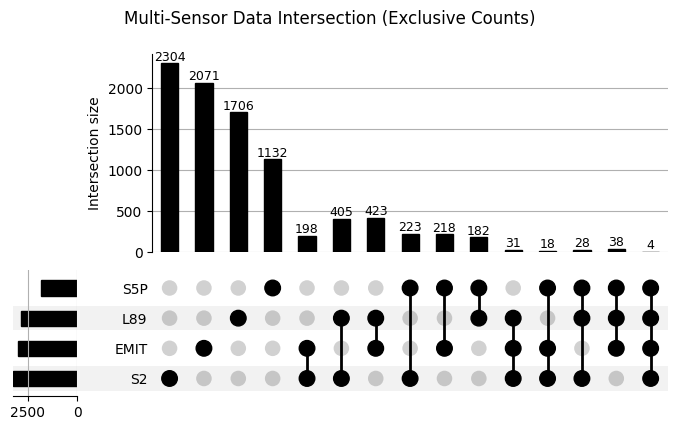

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet

counts_dict = {
    (True,  False, False, False): 2304,
    (False, True,  False, False): 1706,
    (False, False, True,  False): 1132,
    (False, False, False, True ): 2071,
    (True,  True,  False, False): 405,
    (True,  False, True,  False): 223,
    (True,  False, False, True ): 198,
    (False, True,  True,  False): 182,
    (False, True,  False, True ): 423,
    (False, False, True,  True ): 218,
    (True,  True,  True,  False): 28,
    (True,  True,  False, True ): 31,
    (True,  False, True,  True ): 18,
    (False, True,  True,  True ): 38,
    (True,  True,  True,  True ): 4
}

index = pd.MultiIndex.from_tuples(
    counts_dict.keys(),
    names=["S2", "L89", "S5P", "EMIT"]
)

data = pd.Series(list(counts_dict.values()), index=index)

upset = UpSet(
    data,
    subset_size="sum",
    show_counts=False,
    sort_by="degree"
)

axes = upset.plot()

# 获取柱状图 axis
ax = axes["intersections"]

# 在柱子上添加数字
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.suptitle("Multi-Sensor Data Intersection (Exclusive Counts)")
plt.show()

In [1]:
import pandas as pd
import plotly.express as px

paths = {
    "S2": "preprocess_dataset_s2/CM_S2_L2A_CSDE90360.csv",
    "L89": "preprocess_dataset_L89/CM_L89_L2SR_std512.csv",
    "S5P": "preprocess_dataset_s5p/redownload_offl_90360_manifest_with_centers.csv",
    "EMIT": "preprocess_dataset_EMIT/merged_with_emit_tag.csv",
}

# S2: 0 / 90 / 360
s2 = pd.read_csv(paths["S2"])
s2 = s2[s2["s2_path"].notna() & s2["s2_pre_path(-90)"].notna() & s2["s2_pre_pre_path (-360)"].notna()]
s2 = s2[["plume_id", "plume_latitude", "plume_longitude"]].rename(
    columns={"plume_latitude": "lat", "plume_longitude": "lon"}
)
print('s2: ', len(s2))

# L89: 0 / 90 / 360
l89 = pd.read_csv(paths["L89"])
l89 = l89[l89["l89_0_std_512"].notna() & l89["l89_-90_std_512"].notna() & l89["l89_-360_std_512"].notna()]
l89 = l89[["plume_id", "plume_latitude", "plume_longitude"]].rename(
    columns={"plume_latitude": "lat", "plume_longitude": "lon"}
)
print('l89: ', len(l89))

# S5P: 0 / 90 / 360
s5p = pd.read_csv(paths["S5P"])
s5p = s5p[s5p["proc_0"].notna() & s5p["proc_90"].notna() & s5p["proc_360"].notna()]
s5p = s5p[["plume_id", "lat", "lon"]]
print('s5p: ', len(s5p))

# EMIT: 0 / 90 / 180
emit = pd.read_csv(paths["EMIT"])
emit = emit[emit["emit_granule_id"].notna() & emit["emit_-90_granule_id"].notna() & emit["emit_-180_granule_id"].notna()]
print('emit: ', len(emit))
emit = emit[["plume_id", "plume_latitude", "plume_longitude"]].rename(
    columns={"plume_latitude": "lat", "plume_longitude": "lon"}
)

# merge (outer)
df = s2.rename(columns={"lat":"s2_lat","lon":"s2_lon"}) \
    .merge(l89.rename(columns={"lat":"l89_lat","lon":"l89_lon"}), on="plume_id", how="outer") \
    .merge(s5p.rename(columns={"lat":"s5p_lat","lon":"s5p_lon"}), on="plume_id", how="outer") \
    .merge(emit.rename(columns={"lat":"emit_lat","lon":"emit_lon"}), on="plume_id", how="outer")

# 统计每个 plume_id 的传感器组合
def sensors_present(row):
    present = []
    if pd.notna(row["s2_lat"]) and pd.notna(row["s2_lon"]): present.append("S2")
    if pd.notna(row["l89_lat"]) and pd.notna(row["l89_lon"]): present.append("L89")
    if pd.notna(row["s5p_lat"]) and pd.notna(row["s5p_lon"]): present.append("S5P")
    if pd.notna(row["emit_lat"]) and pd.notna(row["emit_lon"]): present.append("EMIT")
    return "+".join(present)

df["combo"] = df.apply(sensors_present, axis=1)

# 转成长表
points = []
for sensor, latcol, loncol in [
    ("S2", "s2_lat", "s2_lon"),
    ("L89", "l89_lat", "l89_lon"),
    ("S5P", "s5p_lat", "s5p_lon"),
    ("EMIT", "emit_lat", "emit_lon"),
]:
    tmp = df[["plume_id", "combo", latcol, loncol]].dropna()
    tmp = tmp.rename(columns={latcol: "lat", loncol: "lon"})
    tmp["sensor"] = sensor
    points.append(tmp)

plot_df = pd.concat(points, ignore_index=True)
plot_df["sensor"] = pd.Categorical(plot_df["sensor"], ["EMIT","S5P","L89","S2"], ordered=True)
plot_df = plot_df.sort_values("sensor")

# 自动配色（基础色平均混合）
base_colors = {
    "S2":  "#d62728",
    "L89": "#2ca02c",
    "S5P": "#ff7f0e",
    "EMIT":"#1f77b4",
}

def hex_to_rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

def rgb_to_hex(rgb):
    return "#%02x%02x%02x" % rgb

def mix_colors(sensors):
    rgbs = [hex_to_rgb(base_colors[s]) for s in sensors]
    r = sum(c[0] for c in rgbs) // len(rgbs)
    g = sum(c[1] for c in rgbs) // len(rgbs)
    b = sum(c[2] for c in rgbs) // len(rgbs)
    return rgb_to_hex((r, g, b))

combos = sorted(plot_df["combo"].unique())
combo_colors = {c: mix_colors(c.split("+")) for c in combos}

# 计算边界和中心
lat_min, lat_max = plot_df["lat"].min(), plot_df["lat"].max()
lon_min, lon_max = plot_df["lon"].min(), plot_df["lon"].max()
center = {"lat": (lat_min + lat_max) / 2, "lon": (lon_min + lon_max) / 2}

# 简单缩放估计（经纬度跨度越大，zoom 越小）
lat_range = max(lat_max - lat_min, 1e-6)
lon_range = max(lon_max - lon_min, 1e-6)
max_range = max(lat_range, lon_range)
zoom = 2.5 - (max_range / 180) * 2.5  # 粗略映射
zoom = max(0.5, min(6, zoom))

fig = px.scatter_geo(
    plot_df,
    lat="lat", lon="lon",
    color="combo",
    opacity=0.6,
    symbol="sensor",           # 关键
    hover_name="plume_id",
    height=700,
    color_discrete_map=combo_colors,
)

fig.update_geos(fitbounds="locations")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()



s2:  3057
l89:  2623
s5p:  1675
emit:  2827


In [2]:
fig = px.scatter_geo(
    plot_df,
    lat="lat", lon="lon",
    color="combo",
    opacity=0.6,
    symbol="sensor",
    hover_name="plume_id",
    height=500,
    color_discrete_map=combo_colors,
)

# ===== 地图背景基础色 =====
fig.update_geos(
    fitbounds="locations",
    showland=True,
    landcolor="#f2f2f2",      # 陆地浅灰
    showocean=True,
    oceancolor="#e6f2ff",     # 海洋浅蓝
    showlakes=True,
    lakecolor="#e6f2ff",
    showcountries=True,
    countrycolor="#bdbdbd",
    coastlinecolor="#bdbdbd",
    showframe=False,
)

# ===== 只保留 3 个 sensor 的 legend =====
wanted_sensors = ["S2", "L89", "S5P", "EMIT"]   # 你要显示的3个
shown = set()

for tr in fig.data:
    # plotly express 这里的 trace.name 一般类似: "S2+L89, S2"
    sensor = tr.name.split(",")[-1].strip()

    if sensor in wanted_sensors and sensor not in shown:
        tr.showlegend = True
        tr.name = sensor
        shown.add(sensor)
    else:
        tr.showlegend = False

fig.update_layout(
    margin={"r": 0, "t": 0, "l": 0, "b": 0},
    legend_title_text="Sensor"
)

fig.show()

In [3]:
import math

def mercator_zoom(lat_min, lat_max, lon_min, lon_max, width_px=1000, height_px=700, pad_px=20):
    # 限制到 Web Mercator 可显示纬度
    lat_min = max(lat_min, -85.05112878)
    lat_max = min(lat_max,  85.05112878)

    def lat2y(lat):
        lat_rad = math.radians(lat)
        return math.log(math.tan(math.pi / 4 + lat_rad / 2))

    # 世界像素大小 = 256 * 2^zoom
    world_px = 256.0

    # 纬度跨度对应的“归一化”高度
    y_min, y_max = lat2y(lat_min), lat2y(lat_max)
    lat_frac = (y_max - y_min) / (2 * math.pi)

    # 经度跨度对应的“归一化”宽度
    lon_frac = (lon_max - lon_min) / 360.0

    # 按画布尺寸估算 zoom（取更严格的一个）
    zoom_lat = math.log2((height_px - 2*pad_px) / (world_px * lat_frac)) if lat_frac > 0 else 20
    zoom_lon = math.log2((width_px  - 2*pad_px) / (world_px * lon_frac)) if lon_frac > 0 else 20
    zoom = min(zoom_lat, zoom_lon)

    # clamp
    return max(0.5, min(18, zoom))

lat_min, lat_max = plot_df["lat"].min(), plot_df["lat"].max()
lon_min, lon_max = plot_df["lon"].min(), plot_df["lon"].max()

center = {"lat": (lat_min + lat_max)/2, "lon": (lon_min + lon_max)/2}
zoom = mercator_zoom(lat_min, lat_max, lon_min, lon_max, width_px=1000, height_px=700, pad_px=30)

fig.update_layout(
    mapbox_center=center,
    mapbox_zoom=zoom,
    width=1000,
    height=700
)


In [ ]:
from graphviz import Digraph

dot = Digraph(comment='End-to-End Multimodal Fusion')
dot.attr(rankdir='LR', nodesep='0.4', ranksep='0.6') # 从左往右

# 1. Inputs
with dot.subgraph(name='cluster_inputs') as c:
    c.attr(label='Multi-modal Inputs', style='dashed')
    for s in ['S2', 'L89', 'S5P', 'WV3']:
        c.node(f'in_{s}', f'{s} Data', shape='cylinder')

# 2. Encoders (PanopticonPE)
for s in ['S2', 'L89', 'S5P', 'WV3']:
    dot.node(f'enc_{s}', f'PanopticonPE\n(Conv3D + ChnAttn)', shape='box', color='orange')
    dot.edge(f'in_{s}', f'enc_{s}')

# 3. Big Shared Backbone (放大)
dot.node('ViT', 'Shared DinoVisionTransformer Backbone\n\n(12 x NestedTensorBlocks)\nWeight Shared Across All Sensors', 
         shape='component', width='3', height='2', style='filled', color='lightblue')

for s in ['S2', 'L89', 'S5P', 'WV3']:
    dot.edge(f'enc_{s}', 'ViT')

# 4. CLS Tokens (4个显式输出)
for i in range(1, 5):
    dot.node(f'cls_{i}', f'CLS_{i}', shape='circle', color='green')
    dot.edge('ViT', f'cls_{i}')

# 5. Branching: Aux Heads & Fusion
with dot.subgraph(name='cluster_aux') as c:
    c.attr(label='Auxiliary Branch', style='dotted')
    c.node('Aux', '4 x Sensor-Specific Heads', shape='box')
    for i in range(1, 5):
        dot.edge(f'cls_{i}', 'Aux')

with dot.subgraph(name='cluster_fusion') as c:
    c.attr(label='Fusion Branch (Row-level)', color='gold', style='filled')
    c.node('Pool', 'MaskedAttentionPooling\n+ Sensor ID Embedding', shape='invhouse')
    c.node('FHead', 'Row Fusion Head', shape='box', style='bold')
    for i in range(1, 5):
        dot.edge(f'cls_{i}', 'Pool')
    dot.edge('Pool', 'FHead')

# 6. Side Loss (侧挂式)
dot.node('Loss', 'Total Loss\nL_fused + λL_aux', shape='note', color='red')
dot.edge('Aux', 'Loss', style='dashed', constraint='false')
dot.edge('FHead', 'Loss', style='dashed', constraint='false')

dot.render('multimodal_v2', format='png', cleanup=True)

In [24]:
from graphviz import Digraph

dot = Digraph(comment='Multimodal Panopticon v3', format='png')
dot.attr(rankdir='LR', nodesep='0.4', ranksep='0.7', splines='ortho')
dot.attr('node', fontname='Arial')

# 1. 细化的输入层 (Data Details)
with dot.subgraph(name='cluster_data') as c:
    c.attr(label='Multi-temporal Heterogeneous Inputs', style='dashed')
    c.node('S2', 'Sentinel-2\n(12 bnds x 3 t = 36)', shape='note', color='#4CAF50')
    c.node('L8', 'Landsat 8/9\n(7 bnds x 3 t = 21)', shape='note', color='#2196F3')
    c.node('S5', 'Sentinel-5P\n(1 bnd x 3 t = 3)', shape='note', color='#FF9800')
    c.node('EM', 'EMIT\n(16 bnds x 3 t = 48)', shape='note', color='#9C27B0')

# 2. Encoder (PanopticonPE)
for s in ['S2', 'L8', 'S5', 'EM']:
    dot.node(f'pe_{s}', 'PanopticonPE\n(Conv3D + ChnAttn)', shape='box', style='filled', fillcolor='#f9f9f9')
    dot.edge(s, f'pe_{s}')

# 3. 巨型共享主干 (Big Backbone)
dot.node('ViT', 'SHARED DinoVisionTransformer BACKBONE\n\n(12 x Transformer Blocks)\n[Parameter Shared Across All Modalities]', 
         shape='component', width='3.7', height='3.5', style='filled', fillcolor='#E3F2FD')

for s in ['S2', 'L8', 'S5', 'EM']:
    dot.edge(f'pe_{s}', 'ViT')

# 4. CLS 向量输出 (矩形表示向量)
for s in ['S2', 'L8', 'S5', 'EM']:
    dot.node(f'cls_{s}', f'CLS_{s}', shape='rect', width='1.2', height='0.3', style='filled', fillcolor='#C8E6C9')
    dot.edge('ViT', f'cls_{s}')

# 5. 主分支：行级融合 (居中)
# dot.node('Pool', 'MaskedAttentionPooling\n(Learnable Sensor ID Emb)', shape='trapezium', style='filled', fillcolor='#FFF9C4')
# dot.node('FHead', 'Row Fusion Head\n(Final Classifier)', shape='box', style='bold,filled', fillcolor='#FFEB3B')

with dot.subgraph(name='cluster_fusion') as c:
    c.attr(label='Fusion Branch (Row-level)', color='gold', style='filled')
    c.node('Pool', 'MaskedAttentionPooling\n+ Sensor ID Embedding', orientation='90', width='3.5', height='1.2', shape='invhouse')
    c.node('FHead', 'Row Fusion Head', shape='box', style='bold')
    dot.edge('Pool', 'FHead')

for s in ['S2', 'L8', 'S5', 'EM']:
    dot.edge(f'cls_{s}', 'Pool')
# dot.edge('Pool', 'FHead', color='#FFC107', penwidth='2')

# 6. 副分支：辅助 Head (下移且使用虚线)
with dot.subgraph(name='cluster_aux') as c:
    # c.attr(label='Auxiliary Supervision', rank='sink')
    c.node('AuxHeads', 'Sensor-specific\nAuxiliary Heads', shape='box', style='dashed', color='grey')
    for s in ['S2', 'L8', 'S5', 'EM']:
        dot.edge(f'cls_{s}', 'AuxHeads', style='dashed', color='grey')

# 7. Total Loss (右下角对齐)
dot.node('Loss', 'TOTAL LOSS\nL_fused + λ * ΣL_aux', shape='septagon', color='red', style='bold')
dot.edge('FHead', 'Loss', style='dotted', constraint='false')
dot.edge('AuxHeads', 'Loss', style='dotted', constraint='false')

dot.render('panopticon_architecture_v3', cleanup=True)

'panopticon_architecture_v3.png'

In [ ]:
from graphviz import Digraph

dot = Digraph(comment='Multimodal Panopticon Final Architecture', format='svg')
dot.attr(rankdir='LR', splines='spline', nodesep='0.55', ranksep='1.0', bgcolor='white')
dot.attr(fontname='Helvetica')
dot.attr('node', fontname='Helvetica', shape='box', style='rounded,filled', color='#444444', penwidth='1.2')
dot.attr('edge', fontname='Helvetica', color='#555555', arrowsize='0.8')

sensors = ['S2', 'L8', 'S5', 'EM']
sensor_info = {
    'S2': 'Sentinel-2\n(12b × 3t = 36)',
    'L8': 'Landsat 8/9\n(7b × 3t = 21)',
    'S5': 'Sentinel-5P\n(1b × 3t = 3)',
    'EM': 'EMIT\n(16b × 3t = 48)'
}

sensor_colors = {
    'S2': '#DCEFD8',
    'L8': '#D8EAF8',
    'S5': '#FCE6C9',
    'EM': '#E9D8F3'
}

# -------------------------
# 1. Inputs
# -------------------------
with dot.subgraph(name='cluster_data') as c:
    c.attr(label='1. Multi-temporal Inputs',
           fontsize='16',
           fontname='Helvetica-Bold',
           color='#BDBDBD',
           style='rounded',
           penwidth='1.2')
    for s in sensors:
        c.node(s, sensor_info[s],
               fillcolor=sensor_colors[s],
               width='1.8',
               height='0.8',
               group=s)

# -------------------------
# 2. PanopticonPE
# -------------------------
with dot.subgraph(name='cluster_pe') as c:
    c.attr(label='PanopticonPE Encoders',
           fontsize='16',
           fontname='Helvetica-Bold',
           color='#CFCFCF',
           style='rounded',
           penwidth='1.2')
    for s in sensors:
        c.node(f'pe_{s}', 'PanopticonPE\n(Conv3D + ChnAttn)',
               fillcolor='#F7F7F7',
               width='1.9',
               height='0.8',
               group=s)

for s in sensors:
    dot.edge(s, f'pe_{s}', penwidth='1.4')

# -------------------------
# 3. Group by Sensor
# -------------------------
dot.node('Group_In',
         'Group by Sensor\n(Batch Flattening)',
         fillcolor='#EEEEEE',
         width='1.9',
         height='0.9')

for s in sensors:
    dot.edge(f'pe_{s}', 'Group_In', penwidth='1.3')

# -------------------------
# 4. Shared Backbone
# -------------------------
dot.node('ViT',
         'SHARED DinoVisionTransformer BACKBONE\n\n'
         '(12 × Transformer Blocks)\n'
         '[Parameter Shared: Serial Processing]',
         fillcolor='#DCEEFF',
         color='#4A90E2',
         penwidth='1.8',
         width='3.2',
         height='1.7')

dot.edge('Group_In', 'ViT', penwidth='1.8')

# -------------------------
# 5. CLS outputs
# -------------------------
for s in sensors:
    dot.node(f'cls_{s}',
             f'CLS_{s}\n(1 × 768)',
             fillcolor='#EAF7E8',
             width='1.3',
             height='0.7',
             group=s)
    dot.edge('ViT', f'cls_{s}', penwidth='1.2')

# -------------------------
# 6. Regroup
# -------------------------
dot.node('Regroup',
         'Regroup by Event ID\n(sample_to_event)',
         fillcolor='#EEEEEE',
         width='2.0',
         height='0.9')

for s in sensors:
    dot.edge(f'cls_{s}', 'Regroup', penwidth='1.2')

# -------------------------
# 7. Fusion stage
# -------------------------
with dot.subgraph(name='cluster_fusion') as c:
    c.attr(label='2. Row-level Fusion Stage',
           fontsize='16',
           fontname='Helvetica-Bold',
           color='#E6D58A',
           style='rounded',
           penwidth='1.2')
    c.node('Pool',
           'MaskedAttentionPooling\n+ Sensor ID Embedding',
           fillcolor='#FFF6CC',
           color='#C9A227',
           penwidth='1.4',
           width='2.2',
           height='0.9')
    c.node('FHead',
           'Row Fusion Head\n(Final Acc)',
           fillcolor='#FFE680',
           color='#C9A227',
           penwidth='1.8',
           width='1.6',
           height='0.85')
    c.edge('Pool', 'FHead', penwidth='1.8')

dot.edge('Regroup', 'Pool', penwidth='1.6')

# -------------------------
# 8. Auxiliary heads
# -------------------------
with dot.subgraph(name='cluster_aux') as c:
    c.attr(label='3. Auxiliary Supervision',
           fontsize='16',
           fontname='Helvetica-Bold',
           color='#D8D8D8',
           style='rounded,dashed',
           penwidth='1.1')
    for s in sensors:
        label = f'{s} Head' if s != 'EM' else 'EMIT Head'
        c.node(f'aux_{s}',
               label,
               fillcolor='#F9F3EC',
               color='#B8A08A',
               style='rounded,filled,dashed',
               penwidth='1.2',
               width='1.4',
               height='0.65',
               group=s)

for s in sensors:
    dot.edge(f'cls_{s}', f'aux_{s}',
             style='dashed',
             color='#888888',
             penwidth='1.0')

# -------------------------
# 9. Loss
# -------------------------
dot.node('Loss',
         'TOTAL LOSS\nL_fused + λ · ΣL_aux',
         shape='hexagon',
         style='filled,bold',
         fillcolor='#FDE2E2',
         color='#D9534F',
         fontcolor='#A12622',
         penwidth='1.8',
         width='1.8',
         height='0.9')

dot.edge('FHead', 'Loss',
         style='dashed',
         color='#C0504D',
         penwidth='1.2',
         constraint='false',
         label='Main CE')

dot.edge('aux_EM', 'Loss',
         style='dashed',
         color='#C0504D',
         penwidth='1.2',
         constraint='false',
         label='Aux CE')

# invisible edges for layout nudging
dot.edge('FHead', 'Loss', style='invis', weight='8')
dot.edge('aux_EM', 'Loss', style='invis', weight='8')

dot.render('panopticon_final_logic_map', cleanup=True)

'panopticon_final_logic_map.png'

In [ ]:
import graphviz
import os

def draw_soft_moe_final():
    dot = graphviz.Digraph(
        name='ViT_Block_SoftMoE',
        format='svg',
        engine='dot'
    )

    dot.attr(rankdir='LR', nodesep='0.4', ranksep='0.7', splines='ortho')
    dot.attr('node', shape='box', style='filled,rounded', fontname='Helvetica')

    # ======================
    # Frozen ViT Block (Top)
    # ======================
    with dot.subgraph() as top:
        top.attr(rank='same')

        dot.node('x', 'x', shape='circle', width='0.3', fillcolor='white')

        dot.node('ln1', 'LayerNorm', fillcolor='#e9ecef', color='#adb5bd')
        dot.node('attn', 'MHSA', fillcolor='#e9ecef', color='#adb5bd')
        dot.node('ls1', 'LayerScale', fillcolor='#e9ecef', color='#adb5bd')
        dot.node('add1', '+', shape='circle', width='0.3', fillcolor='white')

        dot.node('ln2', 'LayerNorm', fillcolor='#e9ecef', color='#adb5bd')
        dot.node('mlp', 'MLP', fillcolor='#e9ecef', color='#adb5bd')
        dot.node('ls2', 'LayerScale', fillcolor='#e9ecef', color='#adb5bd')
        dot.node('add2', '+', shape='circle', width='0.3', fillcolor='white')

        dot.node('y', 'y', shape='circle', width='0.3', fillcolor='white')

    dot.attr(label='Frozen ViT Block (Pre-Norm Transformer)', fontsize='12')

    dot.edge('x', 'ln1')
    dot.edge('ln1', 'attn')
    dot.edge('attn', 'ls1')
    dot.edge('ls1', 'add1')

    dot.edge('add1', 'ln2')
    dot.edge('ln2', 'mlp')
    dot.edge('mlp', 'ls2')
    dot.edge('ls2', 'add2')

    dot.edge('add2', 'y')

    dot.edge('x', 'add1', style='dashed', color='#adb5bd')
    dot.edge('add1', 'add2', style='dashed', color='#adb5bd')

    # ======================
    # Adapter (Bottom, Soft MoE)
    # ======================
    with dot.subgraph(name='cluster_adapter') as c:
        c.attr(
            label='SensorAdapterBlock (Soft MoE View)\n'
                  'shared = global expert, private = domain experts, gate = routing weight',
            style='dashed',
            color='#fd7e14'
        )

        c.node('route', 'Adapter Input', fillcolor='#fff3cd')

        # ---- shared ----
        c.node('shared', 'Shared\n(Global Expert)', fillcolor='#cce5ff')

        c.node('s1', 'Down Projection', shape='trapezium', orientation='270',
               width='0.5', height='1.2', fillcolor='#d9ecff')
        c.node('s2', 'GELU', shape='ellipse', fillcolor='#fff3cd')
        c.node('s3', 'Dropout', fillcolor='#f8f9fa')
        c.node('s4', 'Up Projection', shape='trapezium', orientation='90',
               width='0.5', height='1.2', fillcolor='#d9ecff')

        # ---- private ----
        c.node('private', 'Private\n(Domain Experts)', fillcolor='#d4edda')

        c.node('p1', 'Down Projection', shape='trapezium', orientation='270',
               width='0.5', height='1.2', fillcolor='#def5e5')
        c.node('p2', 'GELU', shape='ellipse', fillcolor='#fff3cd')
        c.node('p3', 'Dropout', fillcolor='#f8f9fa')
        c.node('p4', 'Up Projection', shape='trapezium', orientation='90',
               width='0.5', height='1.2', fillcolor='#def5e5')

        # gate（保持原文字）
        c.node('gate', 'Gate\n(Routing Weight)', shape='ellipse', fillcolor='#e2e3e5')

        # fusion
        c.node('sum', '+', shape='circle', width='0.35', fillcolor='#ffeeba')
        c.node('scale', 'Scaling', fillcolor='#ffeeba')

        # flows
        c.edge('route', 'shared')
        c.edge('shared', 's1')
        c.edge('s1', 's2')
        c.edge('s2', 's3')
        c.edge('s3', 's4')
        c.edge('s4', 'sum')

        c.edge('route', 'private')
        c.edge('private', 'p1')
        c.edge('p1', 'p2')
        c.edge('p2', 'p3')
        c.edge('p3', 'p4')

        # gate inline（不再用 ×）
        c.edge('p4', 'gate')
        c.edge('gate', 'sum')

        c.edge('sum', 'scale')

    # ======================
    # Connect
    # ======================
    dot.edge('x', 'route', color='#fd7e14', label='adapter branch')
    dot.edge('scale', 'add2', color='#fd7e14', label='adapter residual')

    out = 'soft_moe_final_fixed'
    dot.render(out, cleanup=True)
    print(os.path.abspath(out + '.svg'))

if __name__ == '__main__':
    draw_soft_moe_final()

/home/yuyao/methane_train/soft_moe_final_fixed.svg


In [ ]:
from graphviz import Digraph

# Initialize the flowchart with a professional style
dot = Digraph('EMIT_to_WV3_Pipeline', comment='Physics-Informed Spectral Resampling')
dot.attr(rankdir='TB')  
dot.attr('node', shape='box', style='filled,rounded', color='black', fontname='Helvetica,Arial,sans-serif')
dot.attr('edge', fontname='Helvetica,Arial,sans-serif')

# Color schemes
io_color = '#cfe2f3'         # Blue: Input/Output
block1_color = '#d1e7dd'     # Green: Preprocessing
block2_color = '#f8d7da'     # Red: The Physics Core
block3_color = '#fff3cd'     # Yellow: Alignment

# ------------------------------------------------------------------------------------
# Define Nodes

# Input
dot.node('INPUT', 'INPUT:\nRaw EMIT Hyperspectral Cube\n(285 Continuous Bands)', fillcolor=io_color)

# Block 1: Spatial Prep
dot.node('A1', 'Geospatial Cropping &\nLatitude Filtering', fillcolor=block1_color)

# Block 2: THE PHYSICS CORE - Spectral Resampling
dot.node('B1', 'WorldView-3 (WV3) SRF\n(16 Methane-Optimized Bands)', fillcolor=block2_color)
dot.node('B2', 'Radiometric Bandpass Integration\n(GPU Matrix Multiplication)', fillcolor=block2_color)

# Academic Note for the Core (This shows your theoretical depth)
formula_text = (
    "Physics-Informed Dimensionality Reduction:\n"
    "1. Resolves Multicollinearity\n"
    "2. Extracts 2.3μm CH4 Features\n"
    "3. Aligns ViT Channel Complexity"
)
dot.node('B_ANNOT', formula_text, shape='note', fillcolor='#fdfdfe', style='filled', color='black')

# Block 3: Spatial Alignment & Calibration
dot.node('C1', 'Radiometric Alignment\n(Percentile Matching)', fillcolor=block3_color)
dot.node('C2', 'Geospatial Reprojection\n(Local UTM, 60m Grid)', fillcolor=block3_color)

# Output
dot.node('OUTPUT', 'OUTPUT:\nSimulated WV3 Multi-spectral\n(16-Band Information Bottleneck)', fillcolor=io_color)

# ------------------------------------------------------------------------------------
# Define Edges

# Input to Spatial Prep
dot.edge('INPUT', 'A1')

# Core Flow: WV3 SRF applied to integration
dot.edge('B1', 'B2')

# Spatial data goes into the integration process
dot.edge('A1', 'B2', label=' [Apply SRF]')

# Connect the narrative note to the integration step
dot.edge('B2', 'B_ANNOT', style='dotted', arrowhead='none')

# Output of integration to Alignment
dot.edge('B2', 'C1')
dot.edge('C1', 'C2')

# Final Output
dot.edge('C2', 'OUTPUT')

# ------------------------------------------------------------------------------------
# Render
try:
    output_path = dot.render('emit_wv3_simulation_flowchart', view=True, format='png')
    print(f"Flowchart successfully generated and saved to: {output_path}")
except Exception as e:
    print(f"Error rendering flowchart: {e}")

Flowchart successfully generated and saved to: emit_wv3_simulation_flowchart.png


Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)


In [ ]:
from graphviz import Digraph

def draw_panopticon_architecture():
    dot = Digraph(comment='Multi-Sensor Panopticon 4 Overall Boost', format='png')
    dot.attr(rankdir='LR', nodesep='0.5', ranksep='1.0')
    dot.attr('node', fontname='Arial', fontsize='12')

    # 数据输入层
    with dot.subgraph(name='cluster_data'):
        dot.attr(label='Data Input (Wide-table Row)', style='filled', color='lightgrey')
        dot.node('row', 'Multi-Sensor Row\n(S2, L89, S5P, WV3)', shape='box')
        dot.node('collate', 'custom_collate_fn\n(Sample Unrolling)', shape='ellipse')

    # 模型骨干层
    with dot.subgraph(name='cluster_model'):
        dot.attr(label='Core Model (Shared Backbone)', style='filled', color='lightyellow')
        dot.node('pe', 'Sensor-Specific PatchEmbed\n(Adapters)', shape='trapezium', color='blue')
        dot.node('vit', 'DinoViT B/14 Backbone\n(Shared Weights)', shape='rect', style='bold')
        
    # 分支头
    dot.node('s_heads', 'Individual Sensor Heads\n(s2, l89, s5p, wv3)', shape='box', color='blue')
    dot.node('pooling', 'MAP Pooling\n(Masked Attention)', shape='diamond', color='purple')
    dot.node('f_head', 'Row Fusion Head', shape='box', color='purple')
    dot.node('g_head', 'Row Gate Head', shape='box', color='orange')

    # 决策融合
    dot.node('ref_logits', 'Ref Row Logits\n(Mean of Sample Logits)', shape='ellipse')
    dot.node('gate_val', 'Gate (g)', shape='circle', color='orange')
    dot.node('final', 'Final Logits\n(g*Fused + (1-g)*Ref)', shape='star', style='filled', color='gold')

    # 损失函数层
    with dot.subgraph(name='cluster_loss'):
        dot.attr(label='Loss Definition (Total Loss)', style='filled', color='mistyrose')
        dot.node('l_main', 'L_fused_ce\n(Weight: 1.0)', shape='note', color='red')
        dot.node('l_aux', 'L_sensor_aux\n(Weight: 0.3)', shape='note', color='red')
        dot.node('l_single', 'L_single_fused\n(Weight: 0.5)', shape='note', color='red')
        dot.node('l_gate', 'L_gate_bce\n(Weight: 0.02)', shape='note', color='red')

    # 连线：前向流
    dot.edge('row', 'collate')
    dot.edge('collate', 'pe')
    dot.edge('pe', 'vit')
    dot.edge('vit', 's_heads')
    dot.edge('vit', 'pooling')
    dot.edge('pooling', 'f_head')
    dot.edge('pooling', 'g_head')
    dot.edge('s_heads', 'ref_logits')
    dot.edge('f_head', 'final')
    dot.edge('ref_logits', 'final')
    dot.edge('g_head', 'gate_val')
    dot.edge('gate_val', 'final')

    # 连线：损失监督
    dot.edge('final', 'l_main', style='dashed', color='red')
    dot.edge('s_heads', 'l_aux', style='dashed', color='red')
    dot.edge('f_head', 'l_single', label='if Single Sensor', style='dashed', color='red')
    dot.edge('gate_val', 'l_gate', style='dashed', color='red')

    return dot

# 保存并渲染
chart = draw_panopticon_architecture()
chart.render('panopticon_structure', view=True)

'panopticon_structure.png'

Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)
